**Load the saved model and reconstruct the exact test set, imports first**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator  # Replaces AllChem/DataStructs for this
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

gp_full_local = joblib.load("gp_full_local_model.joblib")
scaler_gp = joblib.load("scaler_gp.joblib")
print("Model and scaler loaded successfully.")

# Rebuild the exact same data pipeline (same as 04c) to reproduce the identical test set
df = pd.read_csv("beard_model_ready_features.csv")

# 1. Initialize the new generator ONCE outside the function
n_bits = 256
radius = 2
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)

def get_morgan_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    # 2. Generate the bit vector fingerprint directly as a NumPy array
    return mfpgen.GetFingerprintAsNumPy(mol)

# Apply the function
fp_list = df["canonical_smi"].apply(get_morgan_fp)

# (Optional but recommended) Drop any 'None' values just in case a SMILES failed to parse
# before stacking, otherwise np.stack will throw an error.
fp_list_clean = fp_list.dropna()

fp_matrix = np.stack(fp_list_clean.values)
fp_df = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(n_bits)])

# Note: Ensure we drop NaNs from the main dataframe as well to match the fp_df indices
df_clean = df.loc[fp_list_clean.index].reset_index(drop=True)

X_gp = pd.concat([
    fp_df.reset_index(drop=True), 
    df_clean[["LargestConjugatedSystemSize"]].reset_index(drop=True)
], axis=1)

y_gp = df_clean["lambda_max_exp_nm"].reset_index(drop=True)

X_train_gp, X_test_gp, y_train_gp, y_test_gp = train_test_split(X_gp, y_gp, test_size=0.2, random_state=42)
X_test_gp_scaled = scaler_gp.transform(X_test_gp)

# Also keep the test set's compound identities and metadata for later interpretation
test_indices = X_test_gp.index
df_test_info = df_clean.loc[test_indices].reset_index(drop=True)

print(f"Test set reconstructed: {X_test_gp_scaled.shape}")

Model and scaler loaded successfully.


[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors
[09:00:45] WARNING: not removing hydrogen atom without neighbors


Test set reconstructed: (1376, 257)


[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:46] WARNING: not removing hydrogen atom without neighbors
[09:00:47] WARNING: not removing hydrogen atom without neighbors
[09:00:47] WARNING: not removing hydrogen atom without neighbors
[09:00:47] WARNING: not removing hydrogen atom without neighbors
[09:00:47] WARNING: not r

**Sanity check**

In [2]:
y_pred_test, y_std_test = gp_full_local.predict(X_test_gp_scaled, return_std=True)

df_test_info["y_true"] = y_test_gp.values
df_test_info["y_pred"] = y_pred_test
df_test_info["y_std"] = y_std_test
df_test_info["residual"] = df_test_info["y_true"] - df_test_info["y_pred"]
df_test_info["abs_error"] = df_test_info["residual"].abs()

rmse_check = np.sqrt(mean_squared_error(df_test_info["y_true"], df_test_info["y_pred"]))
print(f"Sanity check RMSE (should match ~92.15 nm): {rmse_check:.2f} nm")

print(df_test_info[["canonical_smi", "y_true", "y_pred", "residual", "abs_error", "y_std"]].describe())

Sanity check RMSE (should match ~92.15 nm): 92.15 nm
            y_true       y_pred     residual    abs_error        y_std
count  1376.000000  1376.000000  1376.000000  1376.000000  1376.000000
mean    406.439438   407.301076    -0.861638    64.568201    98.043876
std     124.886853    75.609288    92.181980    65.773671    12.224283
min     200.000000   205.229386  -291.372996     0.027956    74.278341
25%     317.127500   357.875694   -50.730748    17.441972    89.101521
50%     385.000000   401.530954    -9.029670    42.890194    96.333349
75%     475.250000   449.862411    30.951331    91.324163   105.087245
max     900.000000   751.543734   496.721184   496.721184   141.833481


**Look directly at the best and worst predictions — the natural starting point for mechanistic interpretation,**

In [3]:
# Worst 10 predictions
print("=== WORST 10 PREDICTIONS ===")
worst10 = df_test_info.nlargest(10, "abs_error")[["canonical_smi", "y_true", "y_pred", "residual", "y_std", "LargestConjugatedSystemSize"]]
print(worst10.to_string(index=False))

print("\n=== BEST 10 PREDICTIONS (closest to true value) ===")
best10 = df_test_info.nsmallest(10, "abs_error")[["canonical_smi", "y_true", "y_pred", "residual", "y_std", "LargestConjugatedSystemSize"]]
print(best10.to_string(index=False))

=== WORST 10 PREDICTIONS ===
                                      canonical_smi  y_true     y_pred   residual      y_std  LargestConjugatedSystemSize
                               c1cnc2cc3nccnc3cc2n1   870.0 373.278816 496.721184  83.383898                           14
                Cc1ccc2ccc(C(=O)NCc3ccccc3)c(O)c2n1   800.0 361.681040 438.318960  98.084940                           14
                                                BBF   850.0 445.752542 404.247458  81.542808                            0
                                     NCCCNCCCCNCCCN   885.4 499.155490 386.244510  89.118859                            0
CCSc1cc2c(cc1C=C(C#N)C(=O)O)Sc1ccccc1N2c1ccc(OC)cc1   900.0 520.521502 379.478498 114.196523                           27
                  CCN(CC)c1ccc2cc(C(C)=O)c(=O)oc2c1   850.0 478.208818 371.791182  92.704612                           14
                                         NCCCCNCCCN   880.7 518.045007 362.654993  89.754537                         

**check whether error correlates with how extreme the true λmax is**

In [4]:
df_test_info["distance_from_median"] = (df_test_info["y_true"] - df_test_info["y_true"].median()).abs()

corr_extremity_error = df_test_info["distance_from_median"].corr(df_test_info["abs_error"])
print(f"Correlation between how extreme the TRUE lambda_max is, and prediction error: {corr_extremity_error:.3f}")

# Also directly check: does the model under-predict for high true values specifically? (not just error magnitude)
high_true = df_test_info[df_test_info["y_true"] > df_test_info["y_true"].quantile(0.90)]
print(f"\nFor the top 10% highest true lambda_max compounds (n={len(high_true)}):")
print(f"Mean true value: {high_true['y_true'].mean():.1f} nm")
print(f"Mean predicted value: {high_true['y_pred'].mean():.1f} nm")
print(f"Mean residual (true - pred): {high_true['residual'].mean():.1f} nm")

Correlation between how extreme the TRUE lambda_max is, and prediction error: 0.627

For the top 10% highest true lambda_max compounds (n=135):
Mean true value: 667.8 nm
Mean predicted value: 505.8 nm
Mean residual (true - pred): 162.1 nm


**likely corrupted label**

In [5]:
# Within the top-decile high-lambda_max group, check conjugation extent
print(high_true[["canonical_smi", "y_true", "y_pred", "residual", "LargestConjugatedSystemSize"]].sort_values("LargestConjugatedSystemSize").head(15))

# Quantify: how many of these have suspiciously LOW conjugation for such a high reported lambda_max?
low_conj_high_lambda = high_true[high_true["LargestConjugatedSystemSize"] <= 5]
print(f"\nHigh-lambda_max compounds with conjugation <=5 (likely mislabeled/extraction artifacts): {len(low_conj_high_lambda)} / {len(high_true)}")

                                          canonical_smi  y_true      y_pred  \
736                                                NPOP   707.0  483.860430   
795                                  ClC=C[As](Cl)C=CCl   612.0  445.125696   
988                                          NCCCCNCCCN   880.7  518.045007   
784                                         NCCN1CCOCC1   695.0  437.867514   
105   O=P([O-])([O-])OP(=O)([O-])[O-].[Na+].[Na+].[N...   645.0  342.010545   
1130                                             NCCCCN   724.1  470.978131   
923                                      NCCCNCCCCNCCCN   885.4  499.155490   
181                                            CPN[I]Cl   686.0  495.869494   
54                                           [Ti][I][V]   698.0  462.118086   
330                                             COPCOCl   733.0  423.698118   
451                                       [GaH2][I][I]I   704.0  512.986643   
1286                                                

**recompute the top-decile underprediction statistic excluding these clear artifacts, to get the honest, "genuine chemistry only" number**

In [6]:
# Filter out the likely-artifact compounds (very low conjugation despite claimed high lambda_max)
genuine_high_true = high_true[high_true["LargestConjugatedSystemSize"] > 5]
print(f"Genuine (non-artifact) high-lambda_max compounds: {len(genuine_high_true)} / {len(high_true)}")
print(f"Mean true value: {genuine_high_true['y_true'].mean():.1f} nm")
print(f"Mean predicted value: {genuine_high_true['y_pred'].mean():.1f} nm")
print(f"Mean residual: {genuine_high_true['residual'].mean():.1f} nm")

Genuine (non-artifact) high-lambda_max compounds: 111 / 135
Mean true value: 662.2 nm
Mean predicted value: 515.6 nm
Mean residual: 146.5 nm


**Check the low-λmax tail, mirroring exactly what we did for the high end**

In [7]:
low_true = df_test_info[df_test_info["y_true"] < df_test_info["y_true"].quantile(0.10)]
print(f"For the bottom 10% lowest true lambda_max compounds (n={len(low_true)}):")
print(f"Mean true value: {low_true['y_true'].mean():.1f} nm")
print(f"Mean predicted value: {low_true['y_pred'].mean():.1f} nm")
print(f"Mean residual (true - pred): {low_true['residual'].mean():.1f} nm")

# Same artifact check as before -- suspiciously HIGH conjugation for a very LOW reported lambda_max would be the mirror-image red flag here
print(low_true[["canonical_smi", "y_true", "y_pred", "residual", "LargestConjugatedSystemSize"]].sort_values("LargestConjugatedSystemSize", ascending=False).head(15))

For the bottom 10% lowest true lambda_max compounds (n=137):
Mean true value: 233.2 nm
Mean predicted value: 330.9 nm
Mean residual (true - pred): -97.8 nm
                                          canonical_smi  y_true      y_pred  \
1291  CC(C)(C)c1ccc(-c2nc3c4ccc(-c5ccc6c(c5)c5ccccc5...   258.0  385.017394   
753   c1ccc(N(c2ccccc2)c2ccc(-c3nc4c5ccccc5c5ccccc5c...   258.0  403.588100   
894   c1ccc(-c2cc(-c3ccccc3)cc(-c3nnc(-c4cc(-c5ccccc...   260.0  412.720470   
440   CC(C)(C)c1ccc(-n2c(-c3ccc(-c4ccc(S(=O)(=O)c5cc...   262.0  349.676938   
710   FC(F)(F)c1cc(C#Cc2c3c(c4cccc5cccc2c54)=C(c2ccc...   260.0  474.223888   
931   COc1ccc(-c2nc3c4ccccc4c4ccccc4c3n2-c2ccccc2)c2...   229.0  300.232994   
281   CCCCCCCCCCOc1cc(C(=O)Oc2ccc(-n3cc(-[c-]4cccc4)...   248.0  435.931545   
259   O=S(=O)(O)c1cc2cc(S(=O)(=O)O)c(N=Nc3ccccc3O)c(...   235.0  398.994680   
1181  Cc1c(C(=O)C=Cc2cccc([N+](=O)[O-])c2)nnn1-c1ccn...   233.0  236.075357   
1069  COc1cc(C#Cc2ccc(C#C[Si](C)(C)C)cc2)c(OC)cc1C#C..

**artifact vs. genuine"**

In [8]:
# Mirror the earlier logic: here, the artifact signature is HIGH conjugation with implausibly LOW true lambda_max
artifact_threshold_conj = 20  # large conjugated systems shouldn't show deep-UV-only absorption
low_artifacts = low_true[low_true["LargestConjugatedSystemSize"] > artifact_threshold_conj]
genuine_low_true = low_true[low_true["LargestConjugatedSystemSize"] <= artifact_threshold_conj]

print(f"Low-lambda_max compounds with conjugation >{artifact_threshold_conj} (likely artifacts): {len(low_artifacts)} / {len(low_true)}")
print(f"\nGenuine (non-artifact) low-lambda_max compounds: {len(genuine_low_true)} / {len(low_true)}")
print(f"Mean true value: {genuine_low_true['y_true'].mean():.1f} nm")
print(f"Mean predicted value: {genuine_low_true['y_pred'].mean():.1f} nm")
print(f"Mean residual: {genuine_low_true['residual'].mean():.1f} nm")

Low-lambda_max compounds with conjugation >20 (likely artifacts): 30 / 137

Genuine (non-artifact) low-lambda_max compounds: 107 / 137
Mean true value: 230.6 nm
Mean predicted value: 331.1 nm
Mean residual: -100.5 nm


**predicted-vs-true scatter plot**

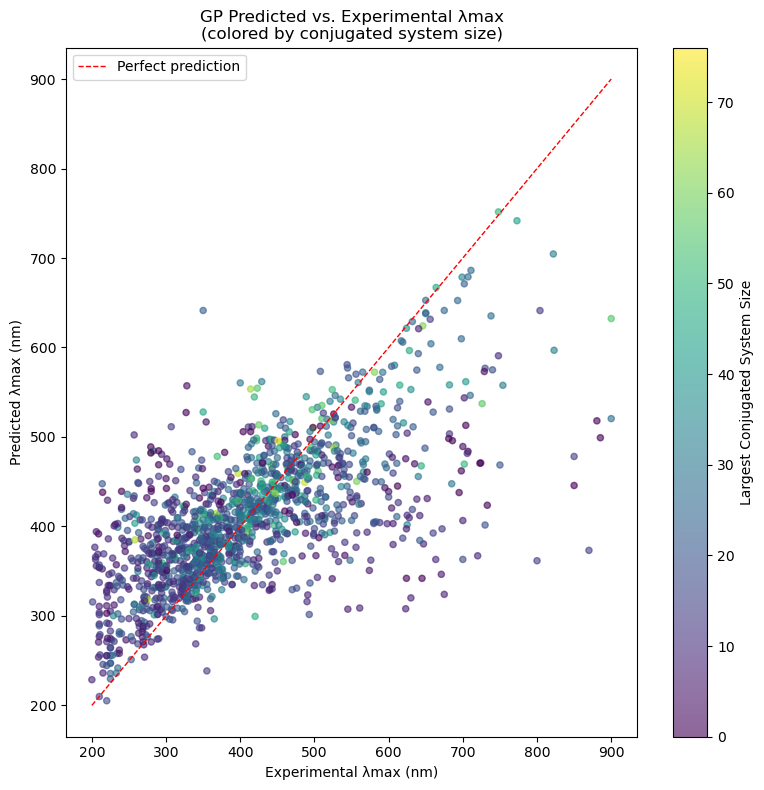

In [9]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df_test_info["y_true"], df_test_info["y_pred"],
    c=df_test_info["LargestConjugatedSystemSize"], cmap="viridis",
    alpha=0.6, s=20
)
plt.plot([200, 900], [200, 900], "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title("GP Predicted vs. Experimental λmax\n(colored by conjugated system size)")
plt.colorbar(sc, label="Largest Conjugated System Size")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_true_lambda_max.png", dpi=300)
plt.show()

**residual vs. conjugation length**

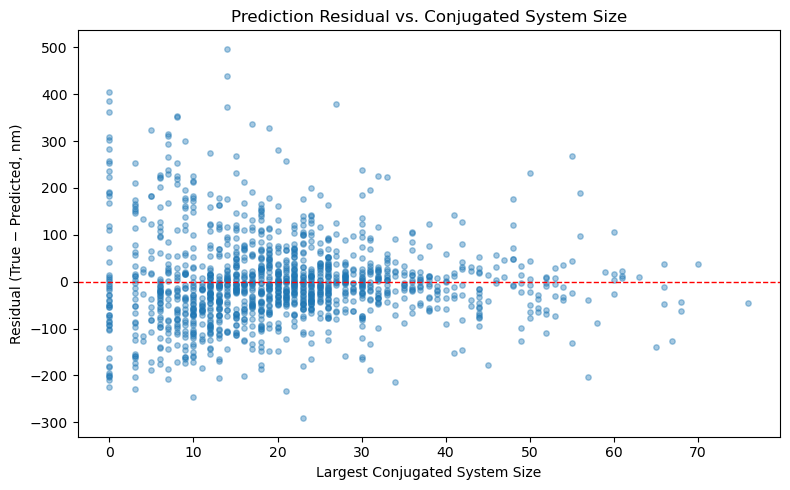

Correlation between conjugation length and signed residual: -0.015


In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df_test_info["LargestConjugatedSystemSize"], df_test_info["residual"], alpha=0.4, s=15)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Largest Conjugated System Size")
plt.ylabel("Residual (True − Predicted, nm)")
plt.title("Prediction Residual vs. Conjugated System Size")
plt.tight_layout()
plt.savefig("residual_vs_conjugation.png", dpi=300)
plt.show()

corr_resid_conj = df_test_info["LargestConjugatedSystemSize"].corr(df_test_info["residual"])
print(f"Correlation between conjugation length and signed residual: {corr_resid_conj:.3f}")